In [7]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



output_dir = Path("/home/a/arfaoui/rag_project/Output_1B")
output_summary = output_dir / "all_experiment_summaries.csv"



def classify_study(chunk_size, top_k):
    """
    Classify experiment into study types.
    """
    if top_k == 5 and chunk_size in [32, 128, 256]:
        return "chunk_size_study"
    elif chunk_size == 128 and top_k in [1, 5, 10]:
        return "topk_study"
    else:
        return "corner_configs"


# 4. Collect all summaries


records = []

for folder in output_dir.glob("*/summary.json"):
    with open(folder, "r") as f:
        summary = json.load(f)

    # Extract fields 
    chunk_size = summary.get("chunk_size")
    top_k = summary.get("top_k")

    record = {
        "model_name": "llama_3.2_1b",  
        "study_type": classify_study(chunk_size, top_k),
        "chunk_size": chunk_size,
        "top_k": top_k,
        "num_examples": summary.get("num_examples"),
        "avg_EM": summary.get("avg_EM"),
        "avg_F1": summary.get("avg_F1"),
        "avg_Recall_at_k_answer": summary.get("avg_Recall@k_answer"),
        "avg_Recall_at_k_support_titles": summary.get("avg_Recall@k_support_titles"),
        "latency_p50": summary.get("latency_p50"),
        "latency_p95": summary.get("latency_p95"),
        
    }

    records.append(record)


# 5. Create DataFrame and save CSV


df = pd.DataFrame(records)

# Sort for readability
df = df.sort_values(by=["chunk_size", "top_k"])

# Save to CSV
df.to_csv(output_summary, index=False)

print("Saved combined CSV to:", output_summary)
display(df)

Saved combined CSV to: /home/a/arfaoui/rag_project/Output_1B/all_experiment_summaries.csv


,model_name,study_type,chunk_size,top_k,num_examples,avg_EM,avg_F1,avg_Recall_at_k_answer,avg_Recall_at_k_support_titles,latency_p50,latency_p95
7,llama_3.2_1b,corner_configs,32,1,7405,0.094801,0.205102,0.204862,0.651992,0.595899,0.608599
8,llama_3.2_1b,chunk_size_study,32,5,7405,0.121269,0.230442,0.423093,0.855503,0.522338,0.744041
4,llama_3.2_1b,corner_configs,32,10,7405,0.125456,0.237461,0.497637,0.904929,0.681379,0.910190
3,llama_3.2_1b,topk_study,128,1,7405,0.117893,0.248145,0.372451,0.784065,0.584761,0.646402
2,llama_3.2_1b,chunk_size_study,128,5,7405,0.148953,0.291226,0.675760,0.928157,0.711976,0.995714
1,llama_3.2_1b,topk_study,128,10,7405,0.161242,0.307459,0.744092,0.954490,1.188749,1.507693
0,llama_3.2_1b,corner_configs,256,1,7405,0.119649,0.253673,0.391492,0.806617,0.580209,0.676666
9,llama_3.2_1b,chunk_size_study,256,5,7405,0.154625,0.300883,0.697502,0.942471,0.793863,1.136021
6,llama_3.2_1b,corner_configs,256,10,7405,0.155706,0.304279,0.763538,0.963403,1.410111,1.903918
5,llama_3.2_1b,corner_configs,512,5,7405,0.154490,0.301687,0.699122,0.944092,0.807864,1.166483


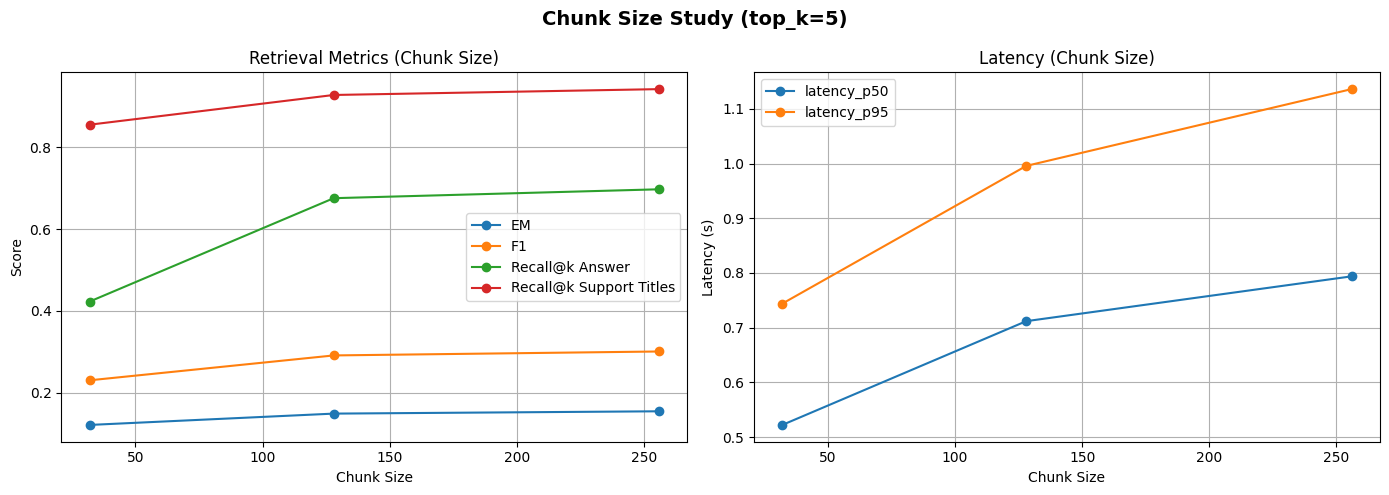

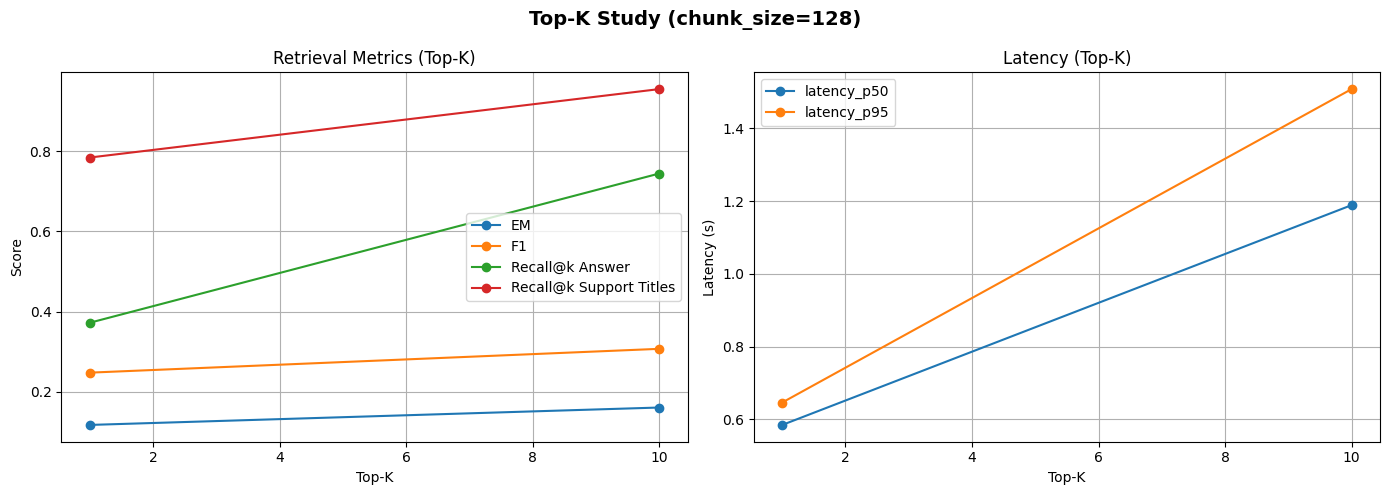

In [8]:
import matplotlib.pyplot as plt

metrics = ["avg_EM", "avg_F1", "avg_Recall_at_k_answer", "avg_Recall_at_k_support_titles"]
latency = ["latency_p50", "latency_p95"]
metric_labels = ["EM", "F1", "Recall@k Answer", "Recall@k Support Titles"]

# Study 1: Chunk Size (top_k=5) 
chunk_study = df[df["study_type"] == "chunk_size_study"].sort_values("chunk_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chunk Size Study (top_k=5)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(chunk_study["chunk_size"], chunk_study[metric], marker="o", label=label)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Chunk Size)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(chunk_study["chunk_size"], chunk_study[col], marker="o", label=col)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Chunk Size)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "chunk_size_study.png", dpi=150)
plt.show()

# Study 2: Top-K (chunk_size=128)
topk_study = df[df["study_type"] == "topk_study"].sort_values("top_k")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-K Study (chunk_size=128)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(topk_study["top_k"], topk_study[metric], marker="o", label=label)
ax.set_xlabel("Top-K")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Top-K)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(topk_study["top_k"], topk_study[col], marker="o", label=col)
ax.set_xlabel("Top-K")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Top-K)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "topk_study.png", dpi=150)
plt.show()

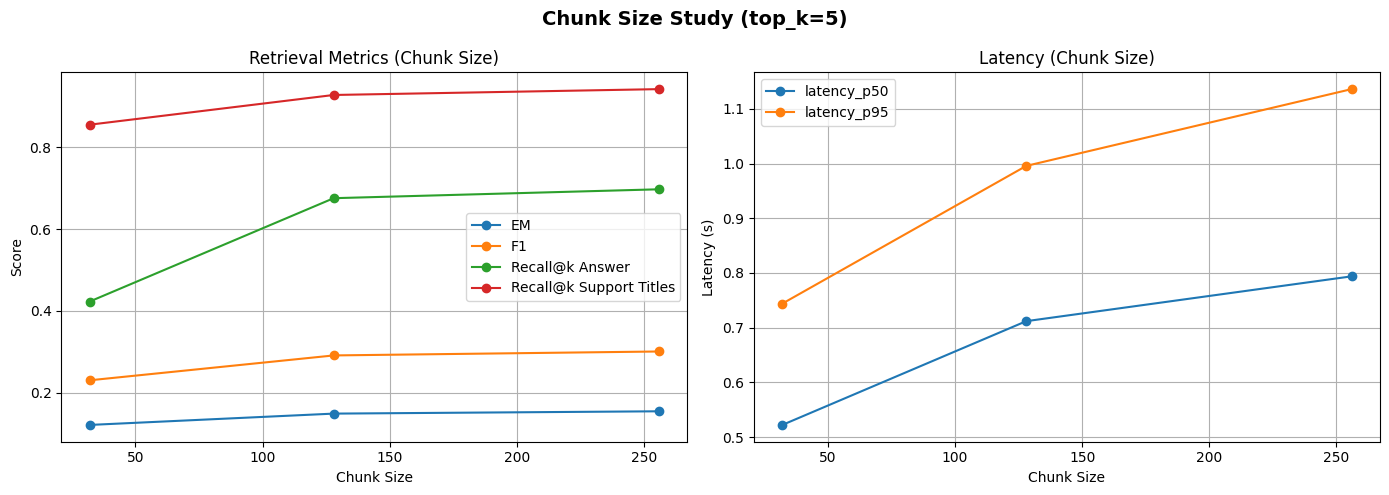

In [12]:
import matplotlib.pyplot as plt

metrics = ["avg_EM", "avg_F1", "avg_Recall_at_k_answer", "avg_Recall_at_k_support_titles"]
latency = ["latency_p50", "latency_p95"]
metric_labels = ["EM", "F1", "Recall@k Answer", "Recall@k Support Titles"]

# Study 1: Chunk Size (top_k=5) 
chunk_study = df[df["study_type"] == "chunk_size_study"].sort_values("chunk_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chunk Size Study (top_k=5)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(chunk_study["chunk_size"], chunk_study[metric], marker="o", label=label)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Chunk Size)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(chunk_study["chunk_size"], chunk_study[col], marker="o", label=col)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Chunk Size)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "chunk_size_study_512.png", dpi=150)
plt.show()

In [13]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt



output_dir = Path("/home/a/arfaoui/rag_project/Output_1B")
output_summary = output_dir / "all_experiment_summaries_512.csv"



def classify_study(chunk_size, top_k):
    """
    Classify experiment into study types.
    """
    if top_k == 5 and chunk_size in [32, 128, 256, 512]:
        return "chunk_size_study"
    elif chunk_size == 128 and top_k in [1, 5, 10]:
        return "topk_study"
    else:
        return "corner_configs"


# 4. Collect all summaries


records = []

for folder in output_dir.glob("*/summary.json"):
    with open(folder, "r") as f:
        summary = json.load(f)

    # Extract fields 
    chunk_size = summary.get("chunk_size")
    top_k = summary.get("top_k")

    record = {
        "model_name": "llama_3.2_1b",  
        "study_type": classify_study(chunk_size, top_k),
        "chunk_size": chunk_size,
        "top_k": top_k,
        "num_examples": summary.get("num_examples"),
        "avg_EM": summary.get("avg_EM"),
        "avg_F1": summary.get("avg_F1"),
        "avg_Recall_at_k_answer": summary.get("avg_Recall@k_answer"),
        "avg_Recall_at_k_support_titles": summary.get("avg_Recall@k_support_titles"),
        "latency_p50": summary.get("latency_p50"),
        "latency_p95": summary.get("latency_p95"),
        
    }

    records.append(record)


# 5. Create DataFrame and save CSV


df = pd.DataFrame(records)

# Sort for readability
df = df.sort_values(by=["chunk_size", "top_k"])

# Save to CSV
df.to_csv(output_summary, index=False)

print("Saved combined CSV to:", output_summary)
display(df)

Saved combined CSV to: /home/a/arfaoui/rag_project/Output_1B/all_experiment_summaries_512.csv


,model_name,study_type,chunk_size,top_k,num_examples,avg_EM,avg_F1,avg_Recall_at_k_answer,avg_Recall_at_k_support_titles,latency_p50,latency_p95
7,llama_3.2_1b,corner_configs,32,1,7405,0.094801,0.205102,0.204862,0.651992,0.595899,0.608599
8,llama_3.2_1b,chunk_size_study,32,5,7405,0.121269,0.230442,0.423093,0.855503,0.522338,0.744041
4,llama_3.2_1b,corner_configs,32,10,7405,0.125456,0.237461,0.497637,0.904929,0.681379,0.910190
3,llama_3.2_1b,topk_study,128,1,7405,0.117893,0.248145,0.372451,0.784065,0.584761,0.646402
2,llama_3.2_1b,chunk_size_study,128,5,7405,0.148953,0.291226,0.675760,0.928157,0.711976,0.995714
1,llama_3.2_1b,topk_study,128,10,7405,0.161242,0.307459,0.744092,0.954490,1.188749,1.507693
0,llama_3.2_1b,corner_configs,256,1,7405,0.119649,0.253673,0.391492,0.806617,0.580209,0.676666
9,llama_3.2_1b,chunk_size_study,256,5,7405,0.154625,0.300883,0.697502,0.942471,0.793863,1.136021
6,llama_3.2_1b,corner_configs,256,10,7405,0.155706,0.304279,0.763538,0.963403,1.410111,1.903918
5,llama_3.2_1b,chunk_size_study,512,5,7405,0.154490,0.301687,0.699122,0.944092,0.807864,1.166483


In [ ]:
import matplotlib.pyplot as plt

metrics = ["avg_EM", "avg_F1", "avg_Recall_at_k_answer", "avg_Recall_at_k_support_titles"]
latency = ["latency_p50", "latency_p95"]
metric_labels = ["EM", "F1", "Recall@k Answer", "Recall@k Support Titles"]

# Study 1: Chunk Size (top_k=5) 
chunk_study = df[df["study_type"] == "chunk_size_study"].sort_values("chunk_size")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chunk Size Study (top_k=5)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(chunk_study["chunk_size"], chunk_study[metric], marker="o", label=label)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Chunk Size)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(chunk_study["chunk_size"], chunk_study[col], marker="o", label=col)
ax.set_xlabel("Chunk Size")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Chunk Size)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "chunk_size_study.png", dpi=150)
plt.show()

# Study 2: Top-K (chunk_size=128)
topk_study = df[df["study_type"] == "topk_study"].sort_values("top_k")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Top-K Study (chunk_size=128)", fontsize=14, fontweight="bold")

# Metrics
ax = axes[0]
for metric, label in zip(metrics, metric_labels):
    ax.plot(topk_study["top_k"], topk_study[metric], marker="o", label=label)
ax.set_xlabel("Top-K")
ax.set_ylabel("Score")
ax.set_title("Retrieval Metrics (Top-K)")
ax.legend()
ax.grid(True)

# Latency
ax = axes[1]
for col in latency:
    ax.plot(topk_study["top_k"], topk_study[col], marker="o", label=col)
ax.set_xlabel("Top-K")
ax.set_ylabel("Latency (s)")
ax.set_title("Latency (Top-K)")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "topk_study.png", dpi=150)
plt.show()